In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned mandi data
df = pd.read_csv("../data/processed/mandi_prices_clean.csv")

# Convert date column
df["arrival_date"] = pd.to_datetime(df["arrival_date"])

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 records:")
display(df.head())

Dataset shape: (98, 7)

Columns:
['market', 'arrival_date', 'arrivals', 'variety', 'minimum_price', 'maximum_price', 'modal_price']

First 5 records:


,market,arrival_date,arrivals,variety,minimum_price,maximum_price,modal_price
0,Bagepalli APMC,2026-09-01,201.0,Tomato,230.0,1600.0,1200.0
1,Bagepalli APMC,2026-09-02,170.0,Tomato,230.0,2300.0,1460.0
2,Bagepalli APMC,2026-09-03,170.0,Tomato,150.0,2070.0,1230.0
3,Bagepalli APMC,2026-09-04,130.0,Tomato,150.0,2100.0,1400.0
4,Bagepalli APMC,2026-09-05,131.7,Tomato,350.0,1800.0,1400.0


In [14]:
# Price statistics by market

market_stats = df.groupby("market")["modal_price"].agg(
    ["count", "mean", "min", "max"]
).sort_values("mean", ascending=False)

market_stats

,count,mean,min,max
market,,,,
Nanjangud APMC,1,3333.000000,3333.0,3333.0
K.R. Pet APMC,1,2000.000000,2000.0,2000.0
T. Narasipura APMC,3,2000.000000,2000.0,2000.0
Mysuru APMC,4,1775.000000,1600.0,2000.0
Gundlupet APMC,5,1660.000000,1500.0,1900.0
Belur APMC,1,1500.000000,1500.0,1500.0
Binny Mill (FF&V) Bengaluru APMC,4,1500.000000,1400.0,1600.0
Hassan APMC,2,1500.000000,1500.0,1500.0
Kanakapura APMC,1,1500.000000,1500.0,1500.0


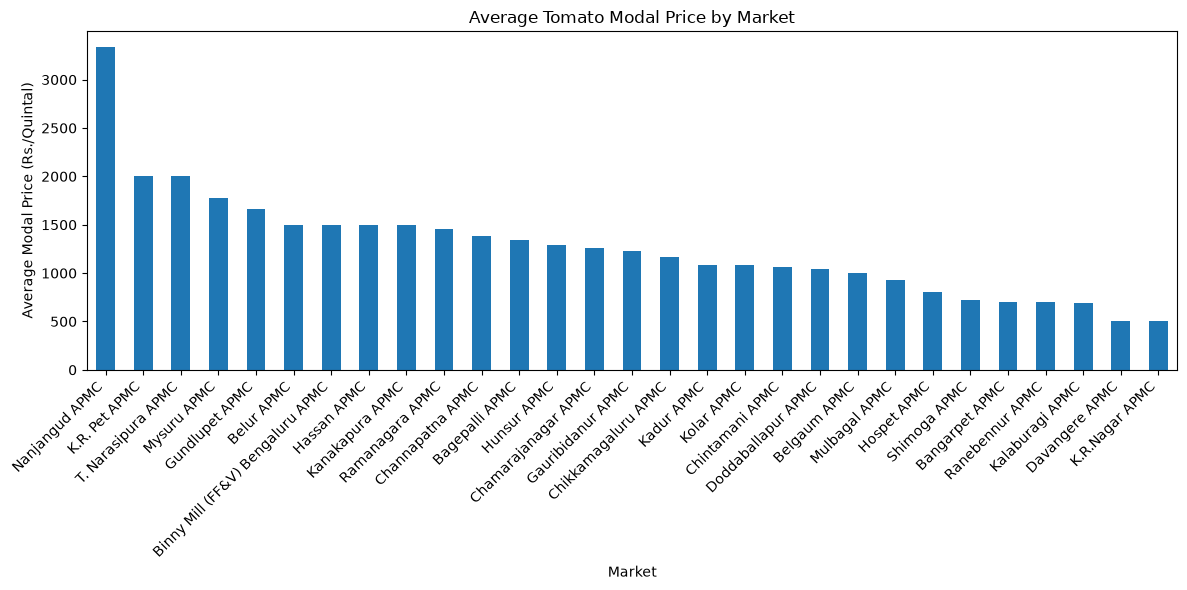

In [15]:
# Average modal price by market

plt.figure(figsize=(12, 6))

market_stats["mean"].sort_values(ascending=False).plot(kind="bar")

plt.title("Average Tomato Modal Price by Market")
plt.xlabel("Market")
plt.ylabel("Average Modal Price (Rs./Quintal)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

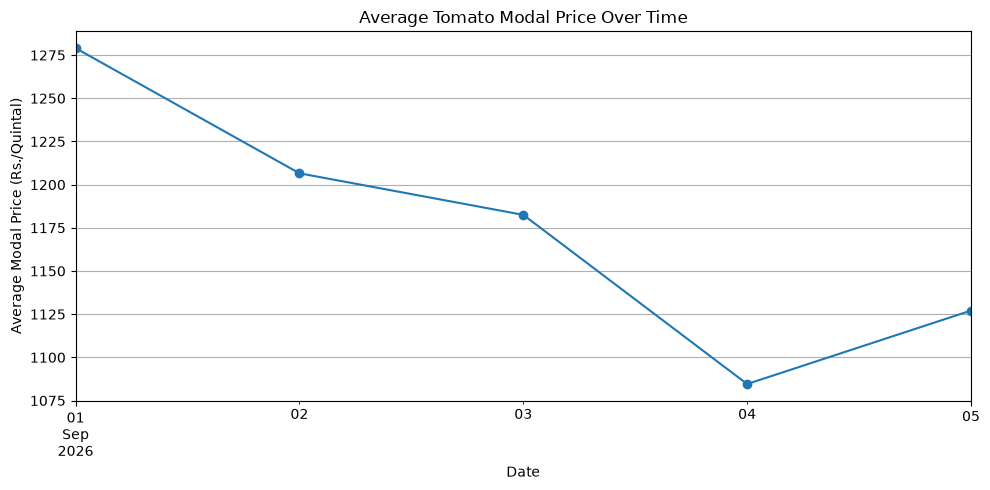

In [16]:
# Average tomato modal price over time

daily_prices = df.groupby("arrival_date")["modal_price"].mean()

plt.figure(figsize=(10, 5))

daily_prices.plot(marker="o")

plt.title("Average Tomato Modal Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Modal Price (Rs./Quintal)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Number of observations available for each market

market_counts = df["market"].value_counts()

market_counts

market
Bagepalli APMC                      5
Bangarpet APMC                      5
Gundlupet APMC                      5
Channapatna APMC                    5
Chamarajanagar APMC                 5
Doddaballapur APMC                  5
Ramanagara APMC                     5
Ranebennur APMC                     5
Davangere APMC                      4
Gauribidanur APMC                   4
Hospet APMC                         4
Binny Mill (FF&V) Bengaluru APMC    4
Chikkamagaluru APMC                 4
Mysuru APMC                         4
Mulbagal APMC                       4
Kalaburagi APMC                     4
Kadur APMC                          4
Shimoga APMC                        4
T. Narasipura APMC                  3
Kolar APMC                          3
Chintamani APMC                     2
Hassan APMC                         2
Hunsur APMC                         2
Belgaum APMC                        1
Belur APMC                          1
Kanakapura APMC                     1
K.R.N